In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display initial information
print("Data Shape:", df.shape)
print("\nData Types and Non-Null Counts:")
df.info()

print("\nFirst 5 rows:")
print(df.head())

Data Shape: (7043, 21)

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         7043 non-null   object 
 1   gender             7043 non-null   object 
 2   Senior_Citizen     7043 non-null   int64  
 3   Is_Married         7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   Phone_Service      7043 non-null   object 
 7   Dual               7043 non-null   object 
 8   Internet_Service   7043 non-null   object 
 9   Online_Security    7043 non-null   object 
 10  Online_Backup      7043 non-null   object 
 11  Device_Protection  7043 non-null   object 
 12  Tech_Support       7043 non-null   object 
 13  Streaming_TV       7043 non-null   object 
 14  Streaming_Movies   7043 non-null   object 
 15  Contract        

In [34]:
# Convert Total_Charges to numeric, handling non-numeric entries (likely spaces)
df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')

# Check for missing values in Total_Charges
missing_total_charges = df['Total_Charges'].isnull().sum()
print(f"\nNumber of missing values in Total_Charges: {missing_total_charges}")

# For a small number of missing values (if any), a good imputation strategy is to replace
# them with the median, especially since these cases often correspond to customers with 0 tenure.

# Customers with 0 tenure likely just signed up, so their Total_Charges should be close to Monthly_Charges.

# However, for simplicity, I will fill with the median for now, or drop them if the count is very low.
# Given the context (Telco Churn), these are likely new customers, so imputing with the median is safer than dropping.

df['Total_Charges'].fillna(df['Total_Charges'].median(), inplace=True)
print("Missing Total_Charges handled by median imputation.")


Number of missing values in Total_Charges: 11
Missing Total_Charges handled by median imputation.


C:\Users\moham\AppData\Local\Temp\ipykernel_18360\1289335074.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total_Charges'].fillna(df['Total_Charges'].median(), inplace=True)


In [35]:
# Convert 'Churn' to a binary numeric column (0 and 1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
churn_counts = df['Churn'].value_counts(normalize=True) * 100

print("\nChurn Distribution:")
print(churn_counts)

# Visualization shows a significant class imbalance: ~73.5% 'No', ~26.5% 'Yes' Goal is to find patterns that predict the minority class (churn).


Churn Distribution:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [36]:
numerical_cols = ['tenure', 'Monthly_Charges', 'Total_Charges']
print("\nNumerical Feature Statistics:")
print(df[numerical_cols].describe())


Numerical Feature Statistics:
            tenure  Monthly_Charges  Total_Charges
count  7043.000000      7043.000000    7043.000000
mean     32.371149        64.761692    2281.916928
std      24.559481        30.090047    2265.270398
min       0.000000        18.250000      18.800000
25%       9.000000        35.500000     402.225000
50%      29.000000        70.350000    1397.475000
75%      55.000000        89.850000    3786.600000
max      72.000000       118.750000    8684.800000


Text(0, 0.5, 'Frequency')

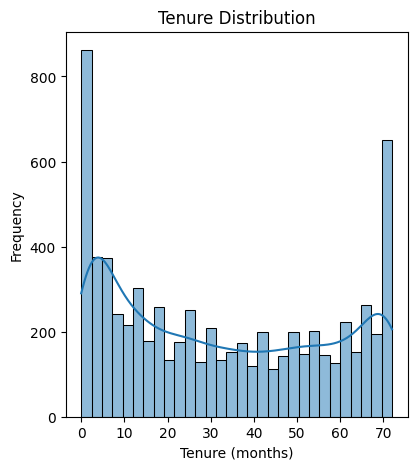

In [37]:
# 1. tenure: Bimodal distribution, with peaks at very low and very high values
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title('Tenure Distribution')
plt.xlabel('Tenure (months)')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

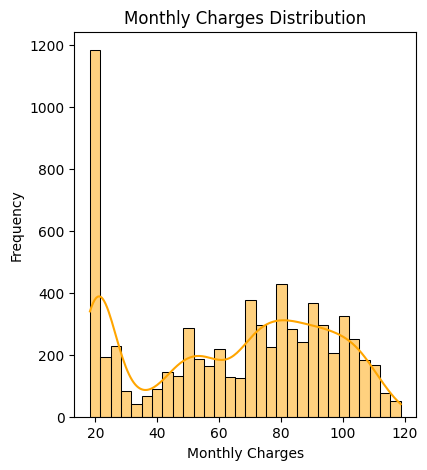

In [38]:
# 2. Monthly_Charges: Skewed towards lower values, but also a cluster around high values (Fiber Optic users).
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 2)
sns.histplot(df['Monthly_Charges'], bins=30, kde=True, color='orange')
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')

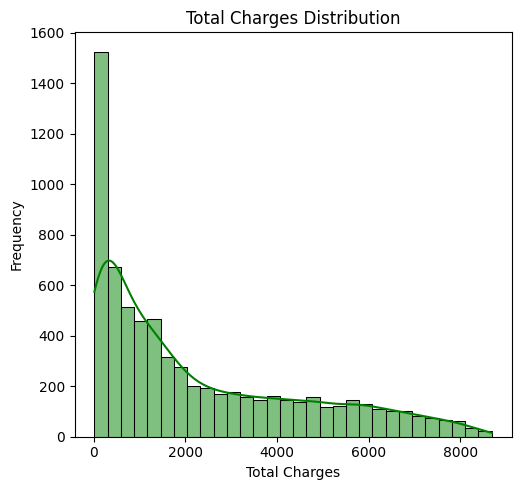

In [39]:
# 3. Total_Charges: Highly skewed, as expected, since it's cumulative.
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 3)
sns.histplot(df['Total_Charges'], bins=30, kde=True, color='green')
plt.title('Total Charges Distribution')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


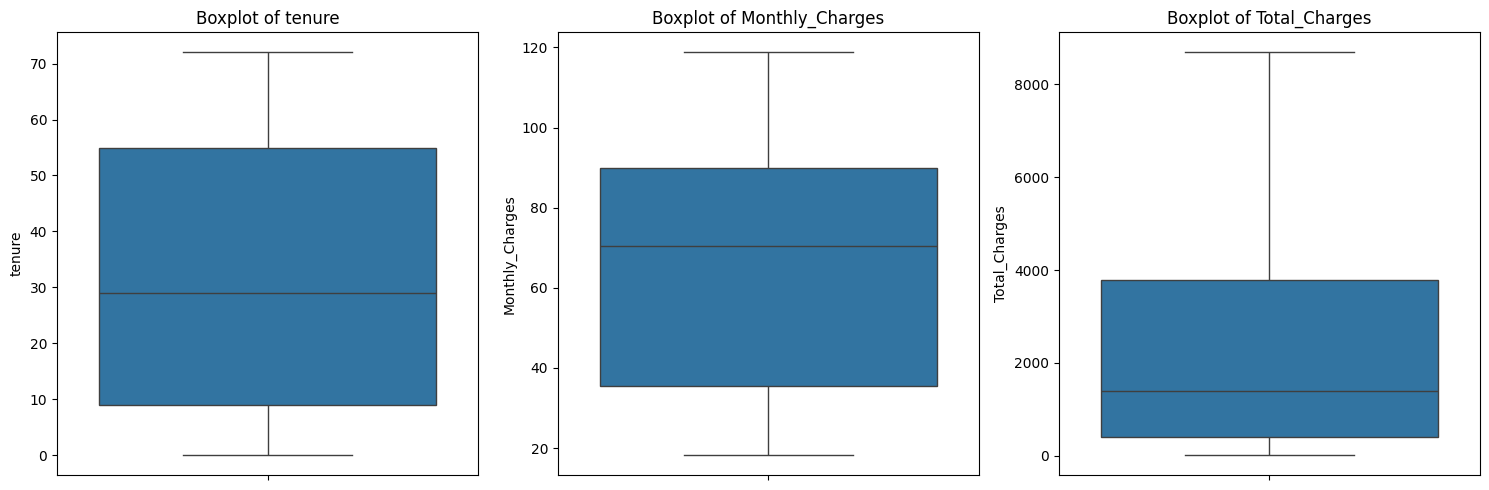

In [40]:

# No severe outliers are apparent that would require aggressive clipping, but scaling is essential.
# boxplot for numerical features
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [41]:
# Identify categorical columns (excluding 'customerID' and numeric ones)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("\nUnique values in key categorical columns:")
for col in ['gender', 'Dependents', 'Phone_Service', 'Internet_Service', 'Contract']:
    print(f"  {col}: {df[col].unique()}")

# (Visualization would show:
# - Contract: Month-to-month has a much higher churn rate.
# - Internet_Service: Fiber optic users churn significantly more.
# - Payment_Method: Electronic check has the highest churn rate.
# - Online_Security/Tech_Support: Lack of these services increases churn.)


Unique values in key categorical columns:
  gender: ['Female' 'Male']
  Dependents: ['No' 'Yes']
  Phone_Service: ['No' 'Yes']
  Internet_Service: ['DSL' 'Fiber optic' 'No']
  Contract: ['Month-to-month' 'One year' 'Two year']


In [42]:
df.columns

Index(['customerID', 'gender', 'Senior_Citizen ', 'Is_Married', 'Dependents',
       'tenure', 'Phone_Service', 'Dual', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn'],
      dtype='object')

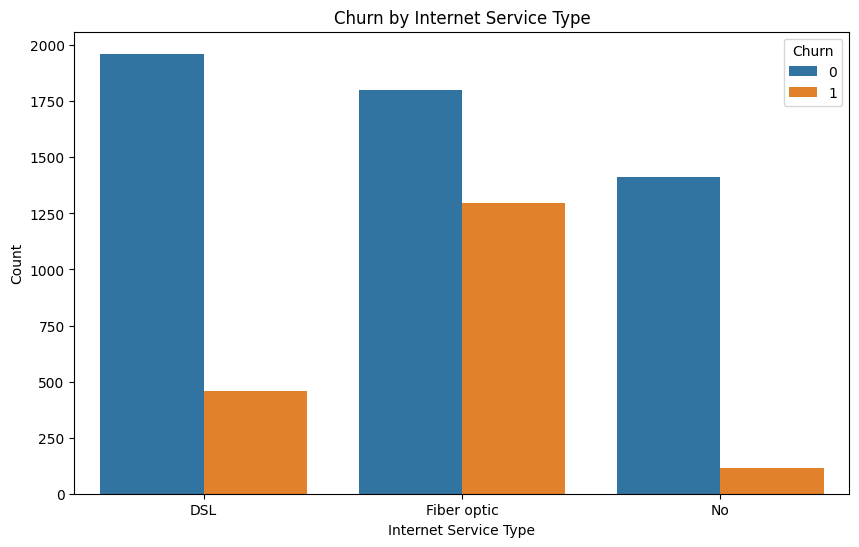

In [45]:
# - Internet_Service: Fiber optic users churn significantly more.
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Internet_Service", hue='Churn')
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service Type')
plt.ylabel('Count')
plt.show()

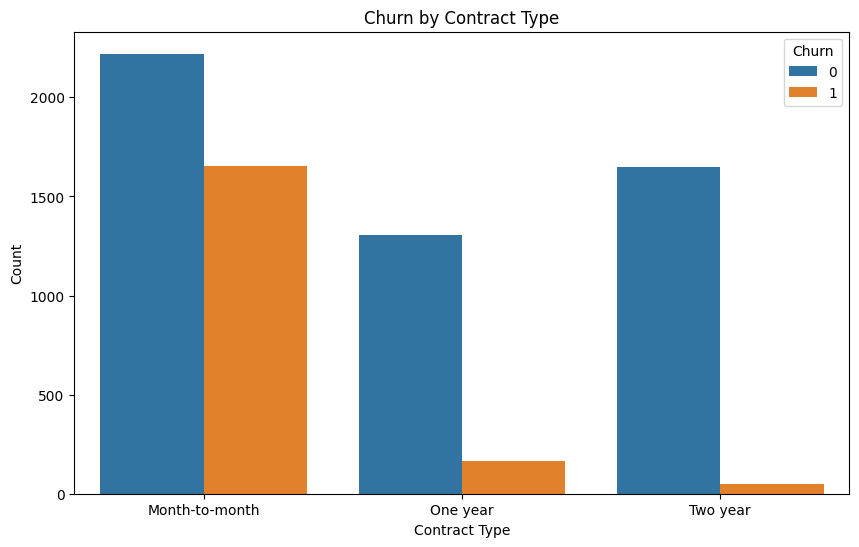

In [46]:
# - Contract: Month-to-month has a much higher churn rate.
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

In [47]:
# Drop the identifier column
df.drop('customerID', axis=1, inplace=True)
print("\nDropped 'customerID'.")


Dropped 'customerID'.


In [48]:
print(df.columns.to_list())

['gender', 'Senior_Citizen ', 'Is_Married', 'Dependents', 'tenure', 'Phone_Service', 'Dual', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn']


In [49]:
# Re-map 'No phone service' and 'No internet service' to 'No'
for col in df.columns:
    if 'No phone service' in df[col].unique():
        df[col] = df[col].replace('No phone service', 'No')
    if 'No internet service' in df[col].unique():
        df[col] = df[col].replace('No internet service', 'No')

# Label Encode binary columns (Yes/No and gender)
binary_cols = [
    'Is_Married', 'Dependents', 'Phone_Service', 'Paperless_Billing',
    'Dual', 'Online_Security', 'Online_Backup', 'Device_Protection',
    'Tech_Support', 'Streaming_TV', 'Streaming_Movies'
]
# For gender (Male/Female)
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

# For Yes/No columns
for col in binary_cols[2:]:
    # Ensure all are Yes/No before mapping (SeniorCitizen is already 0/1)
    if df[col].dtype == 'object':
        df[col] = df[col].map({'No': 0, 'Yes': 1})

print("\nBinary columns label-encoded (Yes/No to 1/0, Female/Male to 0/1).")


Binary columns label-encoded (Yes/No to 1/0, Female/Male to 0/1).


In [50]:
# change Dependents to 0/1
df['Dependents'] = df['Dependents'].map({'No': 0, 'Yes': 1})
df['Is_Married'] = df['Is_Married'].map({'No': 0, 'Yes': 1})

In [51]:
# Identify columns for One-Hot Encoding
ohe_cols = ['Internet_Service', 'Contract', 'Payment_Method']

# Apply One-Hot Encoding
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)
print("Multinomial columns One-Hot Encoded (drop_first=True).")

# Prepare feature matrix X and target vector y
X = df.drop('Churn', axis=1)
y = df['Churn']

Multinomial columns One-Hot Encoded (drop_first=True).


In [52]:
# Identify numerical columns for scaling
numerical_cols = ['tenure', 'Monthly_Charges', 'Total_Charges']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical features
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("\nNumerical features scaled using StandardScaler.")
print("\nFinal Transformed Feature Matrix (X) Head:")
print(X.head())
print(f"Final X shape: {X.shape}")


Numerical features scaled using StandardScaler.

Final Transformed Feature Matrix (X) Head:
   gender  Senior_Citizen   Is_Married  Dependents    tenure  Phone_Service  \
0       0                0           1           0 -1.277445              0   
1       1                0           0           0  0.066327              1   
2       1                0           0           0 -1.236724              1   
3       1                0           0           0  0.514251              0   
4       0                0           0           0 -1.236724              1   

   Dual  Online_Security  Online_Backup  Device_Protection  ...  \
0     0                0              1                  0  ...   
1     0                1              0                  1  ...   
2     0                1              1                  0  ...   
3     0                1              0                  1  ...   
4     0                0              0                  0  ...   

   Paperless_Billing  Monthly

In [ ]:
# Save the transformed data to a CSV for completeness
X_y = X.copy()
X_y['Churn'] = y
# X_y.to_csv('telco_churn_transformed_for_svm.csv', index=False)

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load the transformed data
df_transformed = pd.read_csv('telco_churn_transformed_for_svm.csv')

# 2. Separate features (X) and target (y)
X = df_transformed.drop('Churn', axis=1)
y = df_transformed['Churn']

# 3. Split the data into training and testing sets
# Use a stratify approach to maintain the class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


In [14]:
X_train.dtypes

gender                                      int64
Senior_Citizen                              int64
Is_Married                                  int64
Dependents                                  int64
tenure                                    float64
Phone_Service                               int64
Dual                                        int64
Online_Security                             int64
Online_Backup                               int64
Device_Protection                           int64
Tech_Support                                int64
Streaming_TV                                int64
Streaming_Movies                            int64
Paperless_Billing                           int64
Monthly_Charges                           float64
Total_Charges                             float64
Internet_Service_Fiber optic                 bool
Internet_Service_No                          bool
Contract_One year                            bool
Contract_Two year                            bool


Fitting 3 folds for each of 9 candidates, totalling 27 fits

--- Best Parameters and Score ---
Best Parameters: {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
Best F1-Score (Cross-Validation): 0.6231

--- Model Evaluation on Test Set ---
Accuracy: 0.7490

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1294
           1       0.52      0.78      0.62       467

    accuracy                           0.75      1761
   macro avg       0.71      0.76      0.72      1761
weighted avg       0.80      0.75      0.76      1761



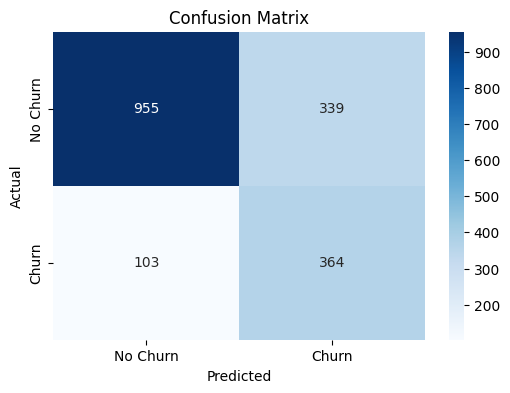

In [ ]:

# 4. Define the parameter grid for GridSearch
# Using a small, representative grid for quick computation and demonstration
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['rbf']
}

# 5. Initialize the SVM model with class_weight='balanced'
# This is crucial for addressing the class imbalance found in the EDA.
svc = SVC(class_weight='balanced', random_state=42)

# 6. Initialize GridSearchCV
# Use 'f1' as the scoring metric since the data is imbalanced and we care about both precision and recall for the positive class (Churn).
grid = GridSearchCV(svc, param_grid, refit=True, verbose=2, cv=3, scoring='f1', n_jobs=-1)

# 7. Fit the model to the training data
grid.fit(X_train, y_train)

# 8. Report the best parameters and score
print("\n--- Best Parameters and Score ---")
print(f"Best Parameters: {grid.best_params_}")
print(f"Best F1-Score (Cross-Validation): {grid.best_score_:.4f}")

# 9. Evaluate the best model on the test set
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\n--- Model Evaluation on Test Set ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# plot confusion matrix for detailed performance
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


In [21]:
# plot learning curve
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
def plot_learning_curve(estimator, X, y, cv=5, scoring='f1'):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring,
        n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(6, 3))
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation score')
    plt.title('Learning Curve')
    plt.xlabel('Training Size')
    plt.ylabel(scoring)
    plt.legend(loc='best')
    plt.grid()
    plt.show()

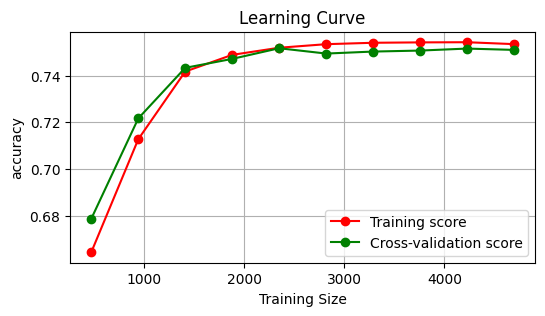

In [20]:
plot_learning_curve(best_model, X, y, cv=3, scoring='accuracy')

In [17]:
# save the best model
import joblib
joblib.dump(best_model, 'svm_churn_model.pkl')

['svm_churn_model.pkl']